In [21]:
%pip install scikit-learn pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


# **Arvores de decisao**
 
Arvores de decisao é um tipo de algoritmo de ML que pode ser usado tanto para regressao quanto classificacao. Essas arvores sao componentes essenciais de modelos muito bons como RandomForest e XGBoost.

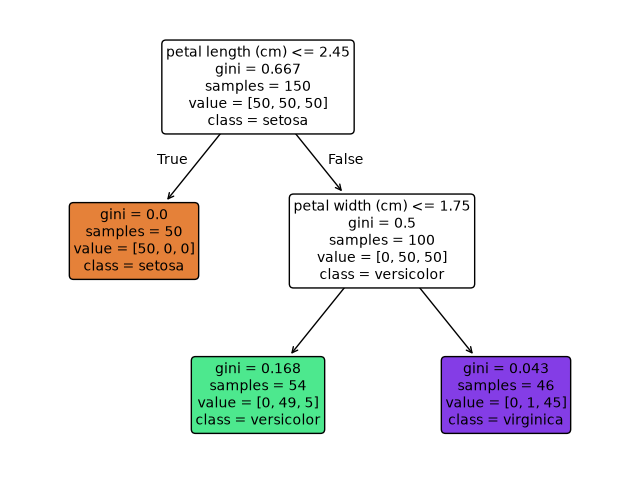

In [22]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

iris = load_iris(as_frame=True)
X_iris = iris['data']
Y_iris = iris['target']

tree_classifier = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_classifier.fit(X_iris, Y_iris)

plt.figure(figsize=(8, 6))
plot_tree(
    tree_classifier,
    feature_names=X_iris.columns,
    class_names=iris['target_names'],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.show()

## **Inferencia** 

Em arvores de decisao existem 2 tipos de nós:

- **split/decision nodes:** Representam nós com *decisoes aprendidas com base nos dados de treino*. Dentro desses nós existe alguma regra (regra binária para arvores binárias mas existem algortimos que aceitam arvores nao binárias) baseada nos dados e alguma coluna, como por exemplo, comprimento da petala <= 2.45 .
- **leaf node:** Folhas do grafo que de fato fazem a predicao e decidem o output.

O processo de inferencia *comeca na raiz da arvore e de acordo com os dados do X que estamos inferindo vamos deslocar pelos nós da arvore ate chegar em uma folha e a predicao ser feita*. Por exemplo, se fizermos inferencia para uma flor com comprimento de petala menor que 2.45 vamos nos deslocar para o nó da esquerda que é uma folha e essa instancia de flor sera classificada como setosa.

Detalhe, por essa inferencia ser feita através de decisoes sem ponderacao de features a* escala das features nao afeta em nada a predicao*.

Cada nó na arvore da imagem é composto por:

- **class:** representa a classe que o nó classificaria as instancias caso ele seja uma folha
- **value:** representa quanto de cada classe existe no nó
- **samples:** representa quantas instancias chegaram naquele nó durante o 
- **gini/entropia:** representa a métrica de qualidade daquele nó (como se fosse uma loss), essa métrica diz o quao indeciso aquele nó esta com base no estado do nó. As métricas mais comuns sao Impureza de Gini e entropia.

### **Interpretacao de modelo**

- **Whitebox:** modelo é transparente por natureza, você consegue entender como ele chega à decisão só de olhar sua estrutura interna. É uma propriedade intrínseca do modelo como arvores de decisao e regressao linear.
- **Blackbox:** Humanamente muito dificil ou impossivel entender como o modelo chegou naquela predicao especifica. Geralmente metodos de explicabilidade sao usados para mitigar.

## **Estimar probabilidade**

A arvore nao apenas faz predicao mas também consegue dizer a probabilidade dessa predicao. *A distribuicao de instancias que cairam naquela folha durante o treino fica armazenado e usando ela é possivel calcular a probabilidade de cada classe naquela folha especifica*. Por exemplo, se 10 instancias durante o treino terminaram naquela folha e temos 3 de uma classe e 7 de outra entao suas respectivas probabilidades sao 30% e 70%. 

- Uma limitacao aqui é que *essa probabilidade é independente das features  mas dependente das regras criadas*, ou seja, **instancias muito diferentes na mesma folha vao ter mesmo probabilidade**. Exemplo: se [1,1.5] e [3,1.5] cair na mesma folha nao interessa se a primeira feature é muito diferente... a probabilidade será a mesma

In [ ]:
proba = tree_classifier.predict_proba([[1,3,4,5]])
print(proba)

proba2 = tree_classifier.predict_proba([[1,15,4,5]])
print(proba2)

[[0.         0.02173913 0.97826087]]
[[0.         0.02173913 0.97826087]]


/home/luis/Documents/Personal/study/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/luis/Documents/Personal/study/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## **Treino**

O treino pode acontecer usando varios algoritmos mas os principais sao o Classification and Regression Tree (CART), implementado no sklearn e que *gera apenas arvores binárias* mas existem outros algoritmos que a arvore nao é mais binária como o ID3.

### **CART**

O algoritmo *recebe um conjunto/subconjunto de instancias de treino e tenta dividir esse conjunto em 2 grupos*. Para dividir as instancias é usado uma feature *k e um limiar t_k dessa feature*. Por exemplo no nó da raiz dividimos o espaco usando a feature k = comprimento da petala e o limiar tk = 2.45 cm.

O problema aqui é como escolher qual feature e limiar dentre as infinitas combinacoes. A ideia é escolher dentre pares (k,t_k) o que *minimiza a funcao de custo J que é a média da pureza dos conjuntos ponderada pelo tamanho dos subconjuntos*.

$$ (k, t_k) = \frac{m_{left} \cdot G_{left} + m_{right} \cdot G_{right}}{m} $$

Em que:
- **G left/right** sao as purezas dos 2 subconjuntos 
- **m left/right** o tamanho deles 
- **m** = m_left + m_right.

A ideia de ser ponderada é *garantir que conjuntos puros maiores tenhama mais peso na Loss que conjuntos pequenos impuros*. Por exemplo, um conjunto de tamanho 2 super impuro e um de tamanho 98 muito puro... sem a ponderacao a loss será alta quando deveria ser baixa.

O processo é *recursivo* entao depois de encontrar a melhor primeira divisão, o CART repete exatamente o *mesmo processo dentro de cada subconjunto criado*, como se cada um fosse um novo problema pequeno. E depois dentro dos sub-subconjuntos. Ele para quando:

- Atinge a *profundidade máxima* (max_depth)
- Não consegue mais achar uma *divisão que reduza a impureza*
- Outros critérios de parada são atingidos: min_samples_split (mínimo de amostras para dividir um nó), min_samples_leaf (mínimo de amostras numa folha), max_leaf_nodes (número máximo de folhas), etc.

#### **Quais pares de testar ?**

Como o numero de (k,t_k) pode crescer infinitamente por causa do limiar a ideia aqui é testar todas as features com *limiares calculados com base no conjunto desse nó*. Se o conjunto tem 3 instancias com features [1,2,3] os limiares testados para essa feature serao [1.5,2.5], ou seja os pontos medios entre os valores da feature ordenadas.

#### **Funcoes de pureza** 

Ambas são formas de medir o quão *"misturado" (impuro) está um conjunto de dados em relação às classes* que ele contém. Quanto mais próximo de zero, mais puro (homogêneo) é o conjunto, ou seja, mais ele contém instâncias de uma única classe.

- **Impureza de Gini:** O somatório de probabilidade só vai ser 1 quando todas as classes no nó forem iguais, ou seja, a impureza só é 0 quando a probabilidade de uma classe/valor ali dentro for 1.

$$ G_i = 1 - \sum_{k=1}^{n} p_{i,k}^2 $$

- **Entropia:** Entropia de uma distribuicao de probabilidade é alta quando existe incerteza, ou seja, todos os valores/classes tem probabilidade parecida. Isso ajuda aqui pois quando a distribuicao de probabilidade em um nó é concentrada em apenas um valor/classe a entropia vai ser 0.

$$ H_i = -\sum_{\substack{k=1 \\ p_{i,k} \neq 0}}^{n} p_{i,k} \log_2\left(p_{i,k}\right) $$


No fim ambas na maioria dos casos *geram resultados muito parecidos* porém como na Gini nao é necessário calcualar log, ela é usada como padrao pois é *mais rapida no treino*. Entropia costuma *gerar arvores um pouco mais balanceadas* fazendo a inferencia do caso médio ser um pouco mais rapida mas nada que justifique.

#### **Complexidade** 

O CART implementado toma decisoes de divisao locais sem pensar no futuro, ou seja, é um **algortimo guloso** que pega sempre o melhor atual e nunca volta atras na sua decisao. 

- A **complexidade de inferencia** dele consiste em descer da raiz da arvore ate alguma folha, ou seja, cresce com a altura dessa arvore que é **O(log2(m))** caso a arvore binária esteja balanceada. 
- A **complexidade de treino** consistem em para cada nó temos que testar a Loss para combinacoes de pares de n features e m-1 limiares de cada feature, ou seja, **n x m pares possiveis** para se testar. Fazemos isso para nivel da arvore pois a soma dos conjuntos de um mesmo nivel é extamente o conjunto total inicial entao a quantidade de vezes que vamos calcular os pares possiveis é **O(log2(m))**. A complexidade entao é **O(n x m x log2(m))**

Consequentemente ele quase nunca vai chegar na solucao otima... um CART que chega na *solucao otima seria um CART que testa todas as arvores possiveis* de serem geradas que gera uma complexidade **exponencial**, que é intratavel.

#### **Hyperparametros de regularizacao**
